## Exercises Day 2 


### Progenetix Exercise 4

Now download the CNV frequency table for:

**Example:**

- Small cell carcinoma, NOS
- filter code: pgx:icdom-80413

**Tasks:**

- download the frequency table
- inspect its shape
- inspect its columns
- Explain why the frequency table has a different shape from the sample table.
    - what one row represents in the sample table
    - what one row represents in the frequency table
    - why these two tables cannot be merged row by row

In [1]:
# Import the packages needed for downloading and processing tabular data.

import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

In [2]:
# Define the intervalFrequencies URLs for the same three groups.

frequency_urls = {
    "Small_cell_carcinoma_NOS": "https://progenetix.org/services/intervalFrequencies/?output=pgxseg&filters=pgx:icdom-80413"
}

In [3]:
# Download the frequency tables.

frequency_tables = {}

for source_query, url in frequency_urls.items():
    print(f"Downloading frequency table for {source_query}")
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    df_freq = pd.read_csv(StringIO(response.text), sep="\t", comment="#")
    df_freq["source_query"] = source_query
    frequency_tables[source_query] = df_freq

In [4]:
# Show the shape of each downloaded frequency table.

for source_query, df_freq in frequency_tables.items():
    print(source_query, df_freq.shape)

Small_cell_carcinoma_NOS (3106, 7)


An analysis of the shape shows that the table consists of 3106 rows and 7 columns.

In [5]:
# Inspect the columns of the frequency table.

frequency_tables["Small_cell_carcinoma_NOS"].columns

Index(['reference_name', 'start', 'end', 'gain_frequency', 'loss_frequency',
       'no', 'source_query'],
      dtype='object')

### Explain different shape

The sample table (1529, 43) has a different shape from the frequency table(3106, 7).
One row in the sample table represents data from one sample. It is thus the 'metadata'.
On the other hand, one row in the frequency table represents how often gains and losses across genomic intervals occur within one diagnostic group. 

These two tables cannot be merged easily, as they represent different levels of data. While the sample table contains metadata, the frequency table consists of gains and losses occuring within one diagnostic group across genomic intervals.

### Classification Exercise 3

In [7]:
# Import libraries

# Standard library tools
import json
import math
import time
from collections import defaultdict

# Data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Progress bars for slow download steps
from tqdm.auto import tqdm

# HTTP requests to the Progenetix Beacon API
import requests

# scikit-learn tools for classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Notebook display helper
from IPython.display import display


In [ ]:
# Choose one bin from the interpretation table

# binid = chr1_130000000_140000000		
# region = chr1:130-140 Mb
# coefficient = -0.365948
# This bin favours Ovarian high-grade serous adenocarcinoma (negative number)

In [1]:
# Plot the data exploratively

# Add readable group labels for plotting.
plot_df = model_df.copy()
plot_df["group_label"] = plot_df["group_code"].map(GROUP_LABELS)

# Just plot the bin selected above
bins_to_plot = (top_negative["bin_id"].head(1).tolist()
)

# Remove duplicates while preserving order.
bins_to_plot = list(dict.fromkeys(bins_to_plot))

for bin_id in bins_to_plot:
    plt.figure(figsize=(6, 4))

    # Plot one histogram per class on the same axes.
    for group_code in [GROUP_1, GROUP_2]:
        values = plot_df.loc[plot_df["group_code"] == group_code, bin_id]
        plt.hist(
            values,
            bins=[-1.5, -0.5, 0.5, 1.5],
            alpha=0.6,
            label=GROUP_LABELS[group_code],
            rwidth=0.9,
        )

    coef_value = coefs[bin_id]
    plt.xticks([-1, 0, 1], ["Deletion (-1)", "No event (0)", "Duplication (+1)"])
    plt.xlabel("CNV state in this genome bin")
    plt.ylabel("Number of samples")
    plt.title(f"{format_bin_label(bin_id)}\nCoefficient = {coef_value:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Progenetix links for the two groups used in this notebook.
progenetix_links = pd.DataFrame({
    "group_code": [GROUP_1, GROUP_2],
    "group_label": [GROUP_LABELS[GROUP_1], GROUP_LABELS[GROUP_2]],
    "collationplot_link": [
        f"https://progenetix.org/services/collationplots/?filters={GROUP_1}",
        f"https://progenetix.org/services/collationplots/?filters={GROUP_2}",
    ],
})

print("Official Progenetix group-level CNV frequency plots")
display(progenetix_links)


NameError: name 'model_df' is not defined

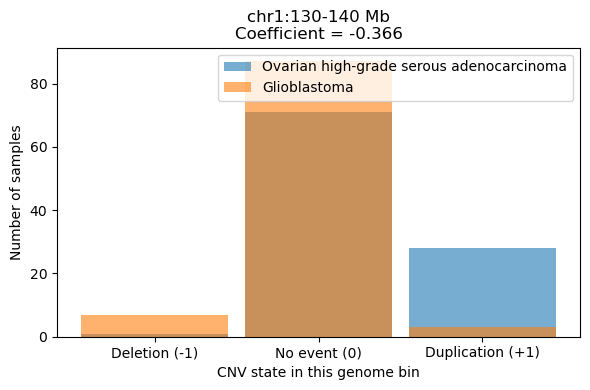

In [1]:
# Plot for ovarian high-grade serous adenocarcinoma

# When regarding chromosome one, there are indeed duplications observable. 
# However, in other chromosomes (chromosome 2, 3, 8, 20) a lot of duplications are observable as well.
# Generally, the results mirror the plot of the ovarian high-grade serous adenocarcinoma quite well. It is interesting however,
# that the hsitogram does not show any deletions (as the plot below would suggest).
# This could indicate, that the CNV does not perfectly match the cancer model of ovarian high-grade serous adenocarcinoma

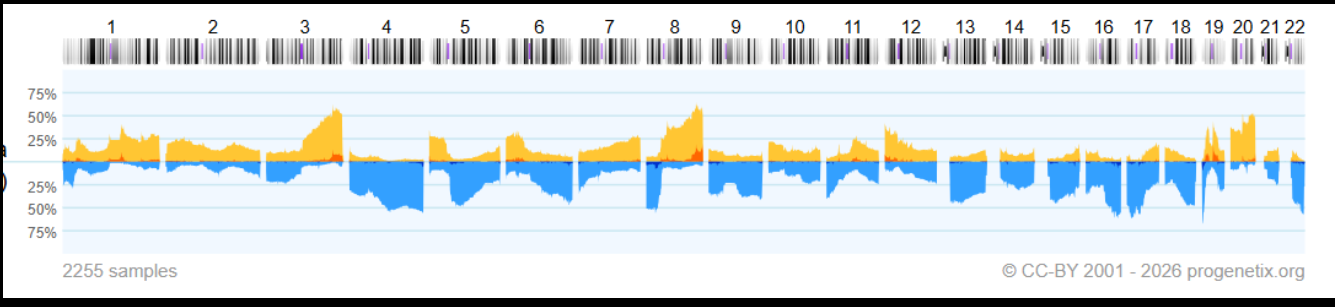

In [ ]:
# Plot for Glioblastoma

# When regarding chromosome one in the plot below a few observations can be made:
# Primarely, there seems to be little changes in this CNV in this disease model. 
# Additionally, deletions and duplications seem to happen similiarly often.
# On other chromosomes (chromosome 7 for instance) a much stronger amplitude of deletions or duplications can be observed.

# Generally, this pattern mirrors our data. However, it is difficult to combine this with our data, 
# as CNVs occur naturally. Without strong amplitude it is difficult to infer
# weither such a change is disease related or just non-medically relevant changes. 

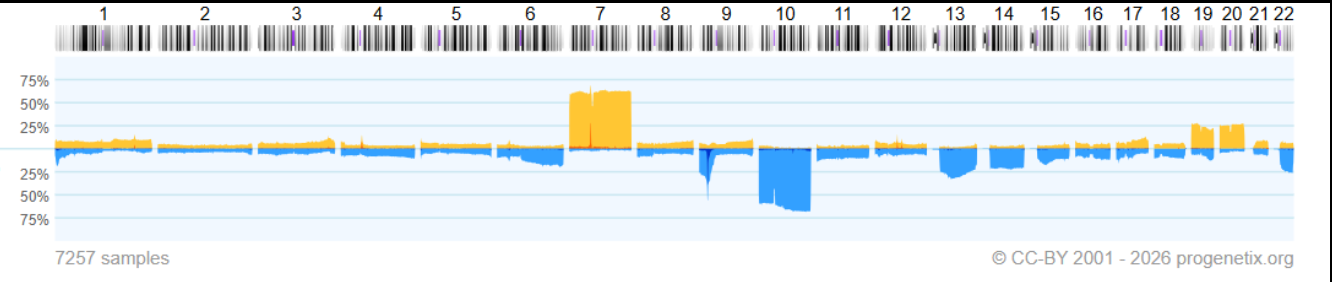